# Custom Factor Landmark Localization

This notebook shows a second use of `gtsam.CustomFactor`: estimating a `Pose2` from relative measurements to known landmarks.

Each factor:

- touches one unknown pose
- stores that pose's landmark measurements
- stacks all landmark residuals into one vector
- fills the Jacobian analytically using `Pose2.transformTo`

This is a good pattern when you already know the residual you want, but do not want to write a full factor class.

GTSAM Copyright 2010-2026, Georgia Tech Research Corporation,
Atlanta, Georgia 30332-0415
All Rights Reserved

Authors: Frank Dellaert, et al. (see THANKS for the full author list)

See LICENSE for the license information

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop/python/gtsam/examples/CustomFactorLocalizationExample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import gtsam
from gtsam.symbol_shorthand import X

np.set_printoptions(precision=3, suppress=True)

## 1. Known Landmarks and Noise Model

We will reuse the same landmarks for every factor. Each factor will correspond to one unknown pose with its own set of landmark measurements.

In [3]:
LANDMARKS = [
    np.array([5.0, 0.0]),
    np.array([2.0, 3.0]),
    np.array([6.0, 4.0]),
]

NOISE_MODEL = gtsam.noiseModel.Isotropic.Sigma(2 * len(LANDMARKS), 0.1)

print("Landmarks:")
for i, landmark in enumerate(LANDMARKS):
    print(f"  L{i}: {landmark}")

Landmarks:
  L0: [5. 0.]
  L1: [2. 3.]
  L2: [6. 4.]


## 2. Residual Object

The residual object is itself the callback passed into `CustomFactor`. This keeps the example short and makes it clear that the factor only needs a callable with the standard `CustomFactor` signature.

In [4]:
def transform_to_jacobian(pose: gtsam.Pose2, point: np.ndarray) -> np.ndarray:
    """Analytical Jacobian of Pose2.transformTo(point) with respect to the pose."""
    dx = point[0] - pose.x()
    dy = point[1] - pose.y()
    c = np.cos(pose.theta())
    s = np.sin(pose.theta())
    return np.array(
        [
            [-c, -s, -s * dx + c * dy],
            [s, -c, -c * dx - s * dy],
        ],
        order="F",
    )


class LandmarkLocalizationResidual:
    """Stack landmark errors for a single Pose2 variable."""

    def __init__(self, measurements: list[np.ndarray]):
        self.measurements = measurements

    def __call__(
        self,
        this: gtsam.CustomFactor,
        values: gtsam.Values,
        jacobians: list[np.ndarray] | None,
    ) -> np.ndarray:
        pose = values.atPose2(this.keys()[0])
        residual = np.zeros(2 * len(self.measurements))

        if jacobians is not None:
            jacobians[0] = np.zeros((2 * len(self.measurements), 3), order="F")

        for i, (landmark, measurement) in enumerate(zip(LANDMARKS, self.measurements)):
            predicted = pose.transformTo(landmark)

            if jacobians is not None:
                # The Python Pose2 wrapper exposes `transformTo` values, so we write the
                # analytical Jacobian explicitly.
                jacobians[0][2 * i : 2 * i + 2, :] = transform_to_jacobian(pose, landmark)

            residual[2 * i : 2 * i + 2] = predicted - measurement

        return residual

## 3. Create Synthetic Measurements

In [5]:
def measure_landmarks(pose: gtsam.Pose2) -> list[np.ndarray]:
    return [pose.transformTo(landmark) for landmark in LANDMARKS]


true_pose0 = gtsam.Pose2(1.0, 2.0, 0.3)
true_pose1 = gtsam.Pose2(2.5, 1.0, -0.2)

measurements0 = measure_landmarks(true_pose0)
measurements1 = measure_landmarks(true_pose1)

print("Measurements at pose 0:")
for measurement in measurements0:
    print(" ", measurement)

Measurements at pose 0:
  [ 3.23030554 -3.0927538 ]
  [1.2508567  0.65981628]
  [5.36772286 0.43307194]


## 4. Inspect One Factor at the Ground Truth

At the correct pose, the residual should be zero. We can also linearize the factor and inspect the Jacobian that the callback produced.

In [6]:
factor = gtsam.CustomFactor(NOISE_MODEL, [X(0)], LandmarkLocalizationResidual(measurements0))

values = gtsam.Values()
values.insert(X(0), true_pose0)

linear = factor.linearize(values)
A, b = linear.jacobian()

print("Nonlinear error:", factor.error(values))
print("Jacobian shape:", A.shape)
A

Nonlinear error: 0.0
Jacobian shape: (6, 3)


array([[ -9.55336489,  -2.95520207, -30.92753805],
       [  2.95520207,  -9.55336489, -32.30305543],
       [ -9.55336489,  -2.95520207,   6.59816282],
       [  2.95520207,  -9.55336489, -12.50856696],
       [ -9.55336489,  -2.95520207,   4.33071945],
       [  2.95520207,  -9.55336489, -53.67722859]])

## 5. Solve for Two Poses

Now we build a tiny graph with two poses. Each pose gets one `CustomFactor` built from the same residual class, but with different measurements.

In [7]:
graph = gtsam.NonlinearFactorGraph()
graph.add(gtsam.CustomFactor(NOISE_MODEL, [X(0)], LandmarkLocalizationResidual(measurements0)))
graph.add(gtsam.CustomFactor(NOISE_MODEL, [X(1)], LandmarkLocalizationResidual(measurements1)))

initial = gtsam.Values()
initial.insert(X(0), gtsam.Pose2(0.2, 0.5, 0.0))
initial.insert(X(1), gtsam.Pose2(3.2, 0.2, 0.1))

result = gtsam.LevenbergMarquardtOptimizer(graph, initial).optimize()

print("True pose 0:     ", true_pose0)
print("Estimated pose 0:", result.atPose2(X(0)))
print()
print("True pose 1:     ", true_pose1)
print("Estimated pose 1:", result.atPose2(X(1)))

True pose 0:      (1, 2, 0.3)

Estimated pose 0: (1.00003, 2.00003, 0.3)


True pose 1:      (2.5, 1, -0.2)

Estimated pose 1: (2.5, 1, -0.2)



## 6. Plot Landmarks, Initial Guesses, and Optimized Poses

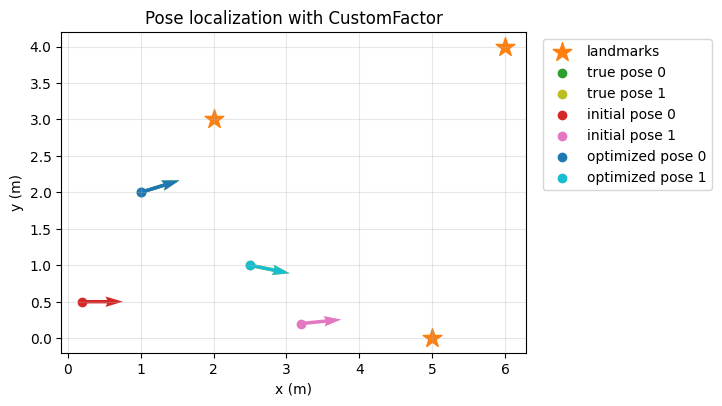

In [8]:
def draw_pose(ax, pose: gtsam.Pose2, color: str, label: str) -> None:
    x, y, theta = pose.x(), pose.y(), pose.theta()
    ax.scatter([x], [y], color=color, label=label)
    ax.quiver(
        [x],
        [y],
        [np.cos(theta)],
        [np.sin(theta)],
        angles="xy",
        scale_units="xy",
        scale=1.8,
        color=color,
    )


fig, ax = plt.subplots(figsize=(6, 6))
landmarks_array = np.array(LANDMARKS)
ax.scatter(
    landmarks_array[:, 0],
    landmarks_array[:, 1],
    marker="*",
    s=200,
    color="tab:orange",
    label="landmarks",
)

draw_pose(ax, true_pose0, "tab:green", "true pose 0")
draw_pose(ax, true_pose1, "tab:olive", "true pose 1")
draw_pose(ax, initial.atPose2(X(0)), "tab:red", "initial pose 0")
draw_pose(ax, initial.atPose2(X(1)), "tab:pink", "initial pose 1")
draw_pose(ax, result.atPose2(X(0)), "tab:blue", "optimized pose 0")
draw_pose(ax, result.atPose2(X(1)), "tab:cyan", "optimized pose 1")

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Pose localization with CustomFactor")
ax.grid(alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.show()

## Takeaways

- `CustomFactor` works well when you already know the residual you want to write.
- A small callable object is often the cleanest way to package measurements and constants.
- You can still use analytical Jacobians, so a custom factor does not have to mean numerical differentiation.